In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt    
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
from io import StringIO
import seaborn as sns




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\joven\miniconda3\envs\setfit_clean\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\joven\miniconda3\envs\setfit_clean\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\joven\miniconda3\envs\setfit_clean\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\joven\miniconda3\envs\setfit_clean\lib\site-packages\traitlets\config\application.py", line 1075, in l

In [2]:
#Load the datasets

price_path_0 = "C:\\Users\\joven\\Documents\\ML Projects\\IMC-Prosperity-4\\Round_2\\CSV Data\\prices_round_2_day_0.csv"
trades_path_0 = "C:\\Users\\joven\\Documents\\ML Projects\\IMC-Prosperity-4\\Round_2\\CSV Data\\trades_round_2_day_0.csv"
price_path_1 = "C:\\Users\\joven\\Documents\\ML Projects\\IMC-Prosperity-4\\Round_2\\CSV Data\\prices_round_2_day_-1.csv"
trades_path_1 = "C:\\Users\\joven\\Documents\\ML Projects\\IMC-Prosperity-4\\Round_2\\CSV Data\\trades_round_2_day_-1.csv"
price_path_2 = "C:\\Users\\joven\\Documents\\ML Projects\\IMC-Prosperity-4\\Round_2\\CSV Data\\prices_round_2_day_1.csv"
trades_path_2 = "C:\\Users\\joven\\Documents\\ML Projects\\IMC-Prosperity-4\\Round_2\\CSV Data\\trades_round_2_day_1.csv"


prices_data_01 = pd.read_csv(price_path_1, sep=";")
trades_data_01 = pd.read_csv(trades_path_1, sep=";")
prices_data_02 = pd.read_csv(price_path_2, sep=";")
trades_data_02 = pd.read_csv(trades_path_2, sep=";")
prices_data_0 = pd.read_csv(price_path_0, sep=";")
trades_data_0 = pd.read_csv(trades_path_0, sep=";")



print(prices_data_01.shape[0])
print(trades_data_01.shape[0])

prices_data_01

20000
790


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11009.0,25.0,NaN,NaN,NaN,NaN,11001.5,0.0
1,-1,0,ASH_COATED_OSMIUM,9982.0,21.0,NaN,NaN,NaN,NaN,10000.0,13.0,10003.0,21.0,NaN,NaN,9991.0,0.0
2,-1,100,ASH_COATED_OSMIUM,9984.0,15.0,NaN,NaN,NaN,NaN,10000.0,15.0,10003.0,26.0,NaN,NaN,9992.0,0.0
3,-1,100,INTARIAN_PEPPER_ROOT,10994.0,8.0,10991.0,22.0,NaN,NaN,11006.0,8.0,11009.0,22.0,NaN,NaN,11000.0,0.0
4,-1,200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,30.0,NaN,NaN,10001.0,15.0,NaN,NaN,NaN,NaN,9993.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-1,999700,INTARIAN_PEPPER_ROOT,11993.0,11.0,NaN,NaN,NaN,NaN,12006.0,11.0,12009.0,23.0,NaN,NaN,11999.5,0.0
19996,-1,999800,INTARIAN_PEPPER_ROOT,11993.0,9.0,11990.0,24.0,NaN,NaN,12006.0,9.0,NaN,NaN,NaN,NaN,11999.5,0.0
19997,-1,999800,ASH_COATED_OSMIUM,9994.0,10.0,9992.0,27.0,NaN,NaN,10013.0,27.0,NaN,NaN,NaN,NaN,10003.5,0.0
19998,-1,999900,ASH_COATED_OSMIUM,9994.0,15.0,9992.0,24.0,NaN,NaN,10010.0,15.0,10013.0,24.0,NaN,NaN,10002.0,0.0


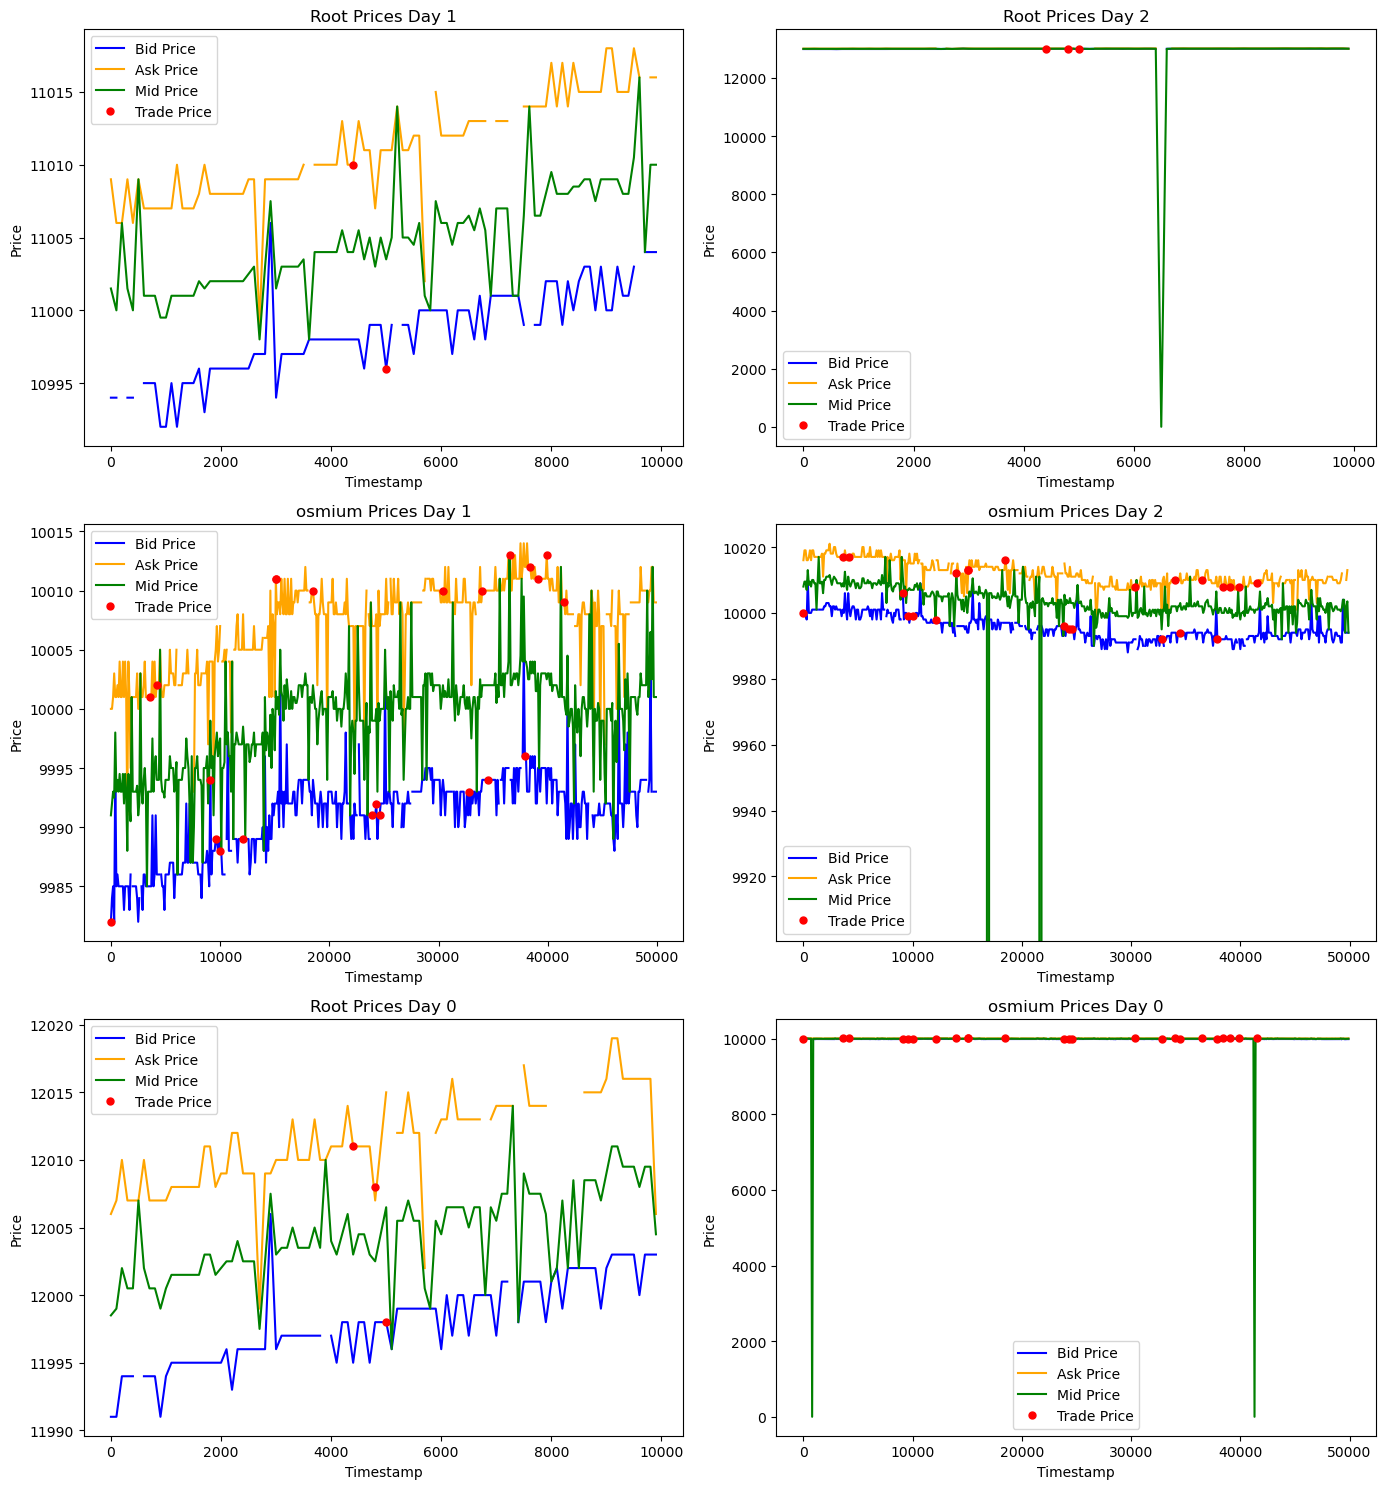

In [12]:
# split tomato and emerald data
prices_data_01_root = prices_data_01[prices_data_01['product'] == 'INTARIAN_PEPPER_ROOT'].drop(columns=['product']).copy()
prices_data_01_osmium = prices_data_01[prices_data_01['product'] == 'ASH_COATED_OSMIUM'].drop(columns=['product']).copy()
prices_data_02_root = prices_data_02[prices_data_02['product'] == 'INTARIAN_PEPPER_ROOT'].drop(columns=['product']).copy()
prices_data_02_osmium = prices_data_02[prices_data_02['product'] == 'ASH_COATED_OSMIUM'].drop(columns=['product']).copy()
prices_data_0_root = prices_data_0[prices_data_0['product'] == 'INTARIAN_PEPPER_ROOT'].drop(columns=['product']).copy() 
prices_data_0_osmium = prices_data_0[prices_data_0['product'] == 'ASH_COATED_OSMIUM'].drop(columns=['product']).copy()  

trades_data_01_root = trades_data_01[trades_data_01['symbol'] == 'INTARIAN_PEPPER_ROOT'].drop(columns=['symbol']).copy()
trades_data_01_osmium = trades_data_01[trades_data_01['symbol'] == 'ASH_COATED_OSMIUM'].drop(columns=['symbol']).copy()
trades_data_02_root = trades_data_02[trades_data_02['symbol'] == 'INTARIAN_PEPPER_ROOT'].drop(columns=['symbol']).copy()
trades_data_02_osmium = trades_data_02[trades_data_02['symbol'] == 'ASH_COATED_OSMIUM'].drop(columns=['symbol']).copy()
trades_data_0_root = trades_data_0[trades_data_0['symbol'] == 'INTARIAN_PEPPER_ROOT'].drop(columns=['symbol']).copy()
trades_data_0_osmium = trades_data_0[trades_data_0['symbol'] == 'ASH_COATED_OSMIUM'].drop(columns=['symbol']).copy()


fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(14, 15))


root_pv = 100

#filter trades up to osmium_pv
trades_data_01_root = trades_data_01_root[trades_data_01_root["timestamp"] <= root_pv*100]
trades_data_02_root = trades_data_02_root[trades_data_02_root["timestamp"] <= root_pv*100]
trades_data_0_root = trades_data_0_root[trades_data_0_root["timestamp"] <= root_pv*100]

#root day 0
ax5.plot(prices_data_0_root["timestamp"][:root_pv], prices_data_0_root["bid_price_1"][:root_pv], label="Bid Price", color="blue")
ax5.plot(prices_data_0_root["timestamp"][:root_pv], prices_data_0_root["ask_price_1"][:root_pv], label="Ask Price", color="orange")
ax5.plot(prices_data_0_root["timestamp"][:root_pv], prices_data_0_root["mid_price"][:root_pv  ], label="Mid Price", color="green")
ax5.plot(trades_data_0_root["timestamp"], trades_data_0_root["price"], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax5.set_title("Root Prices Day 0")
ax5.set_xlabel("Timestamp")
ax5.set_ylabel("Price")
ax5.legend()


# root day -1

ax1.plot(prices_data_01_root["timestamp"][:root_pv], prices_data_01_root["bid_price_1"][:root_pv], label="Bid Price", color="blue")
ax1.plot(prices_data_01_root["timestamp"][:root_pv], prices_data_01_root["ask_price_1"][:root_pv], label="Ask Price", color="orange")
ax1.plot(prices_data_01_root["timestamp"][:root_pv], prices_data_01_root["mid_price"][:root_pv  ], label="Mid Price", color="green")
ax1.plot(trades_data_01_root["timestamp"], trades_data_01_root["price"], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax1.set_title("Root Prices Day 1")
ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Price")
ax1.legend()

# root day -2
ax2.plot(prices_data_02_root["timestamp"][:root_pv], prices_data_02_root["bid_price_1"][:root_pv], label="Bid Price", color="blue")
ax2.plot(prices_data_02_root["timestamp"][:root_pv], prices_data_02_root["ask_price_1"][:root_pv], label="Ask Price", color="orange")
ax2.plot(prices_data_02_root["timestamp"][:root_pv], prices_data_02_root["mid_price"][:root_pv  ], label="Mid Price", color="green")
ax2.plot(trades_data_02_root["timestamp"], trades_data_02_root["price"], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax2.set_title("Root Prices Day 2")
ax2.set_xlabel("Timestamp")
ax2.set_ylabel("Price")
ax2.legend()



osmium_pv = 500

#filter trades up to osmium_pv
trades_data_01_osmium = trades_data_01_osmium[trades_data_01_osmium["timestamp"] <= osmium_pv*100]
trades_data_02_osmium = trades_data_02_osmium[trades_data_02_osmium["timestamp"] <= osmium_pv*100]
trades_data_0_osmium = trades_data_0_osmium[trades_data_0_osmium["timestamp"] <= osmium_pv*100]

#osmium day 0
ax6.plot(prices_data_0_osmium["timestamp"][:osmium_pv], prices_data_0_osmium["bid_price_1"][:osmium_pv], label="Bid Price", color="blue")
ax6.plot(prices_data_0_osmium["timestamp"][:osmium_pv], prices_data_0_osmium["ask_price_1"][:osmium_pv], label="Ask Price", color="orange")
ax6.plot(prices_data_0_osmium["timestamp"][:osmium_pv], prices_data_0_osmium["mid_price"][:osmium_pv], label="Mid Price ", color="green")
ax6.plot(trades_data_0_osmium["timestamp"][:osmium_pv], trades_data_0_osmium ["price"][:osmium_pv], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)   
ax6.set_title("osmium Prices Day 0")
ax6.set_xlabel("Timestamp")
ax6.set_ylabel("Price")
ax6.legend()

#OSMIUM DAY -1
ax3.plot(prices_data_01_osmium["timestamp"][:osmium_pv], prices_data_01_osmium["bid_price_1"][:osmium_pv], label="Bid Price", color="blue")
ax3.plot(prices_data_01_osmium["timestamp"][:osmium_pv], prices_data_01_osmium["ask_price_1"][:osmium_pv], label="Ask Price", color="orange")
ax3.plot(prices_data_01_osmium["timestamp"][:osmium_pv], prices_data_01_osmium["mid_price"][:osmium_pv], label="Mid Price", color="green")
ax3.plot(trades_data_01_osmium["timestamp"][:osmium_pv], trades_data_01_osmium["price"][:osmium_pv], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax3.set_title("osmium Prices Day 1")
ax3.set_xlabel("Timestamp")
ax3.set_ylabel("Price")
ax3.legend()

# osmium day -2
ax4.plot(prices_data_02_osmium["timestamp"][:osmium_pv], prices_data_02_osmium["bid_price_1"][:osmium_pv], label="Bid Price", color="blue")
ax4.plot(prices_data_02_osmium["timestamp"][:osmium_pv], prices_data_02_osmium["ask_price_1"][:osmium_pv], label="Ask Price", color="orange")
ax4.plot(prices_data_02_osmium["timestamp"][:osmium_pv], prices_data_02_osmium["mid_price"][:osmium_pv], label="Mid Price", color="green")
ax4.plot(trades_data_02_osmium["timestamp"][:osmium_pv], trades_data_02_osmium["price"][:osmium_pv], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax4.set_title("osmium Prices Day 2")
#SET Y LIM TO AVERAGE OF MID PRICE +/- 0.1*STD DEV OF MID PRICE
mid_price_mean = prices_data_02_osmium["mid_price"][:osmium_pv].mean()
mid_price_std = prices_data_02_osmium["mid_price"][:osmium_pv].std()
ax4.set_ylim(mid_price_mean - 0.1* mid_price_std, mid_price_mean + 0.1*mid_price_std)

ax4.set_xlabel("Timestamp")
ax4.set_ylabel("Price")
ax4.legend()


plt.tight_layout()
plt.show()


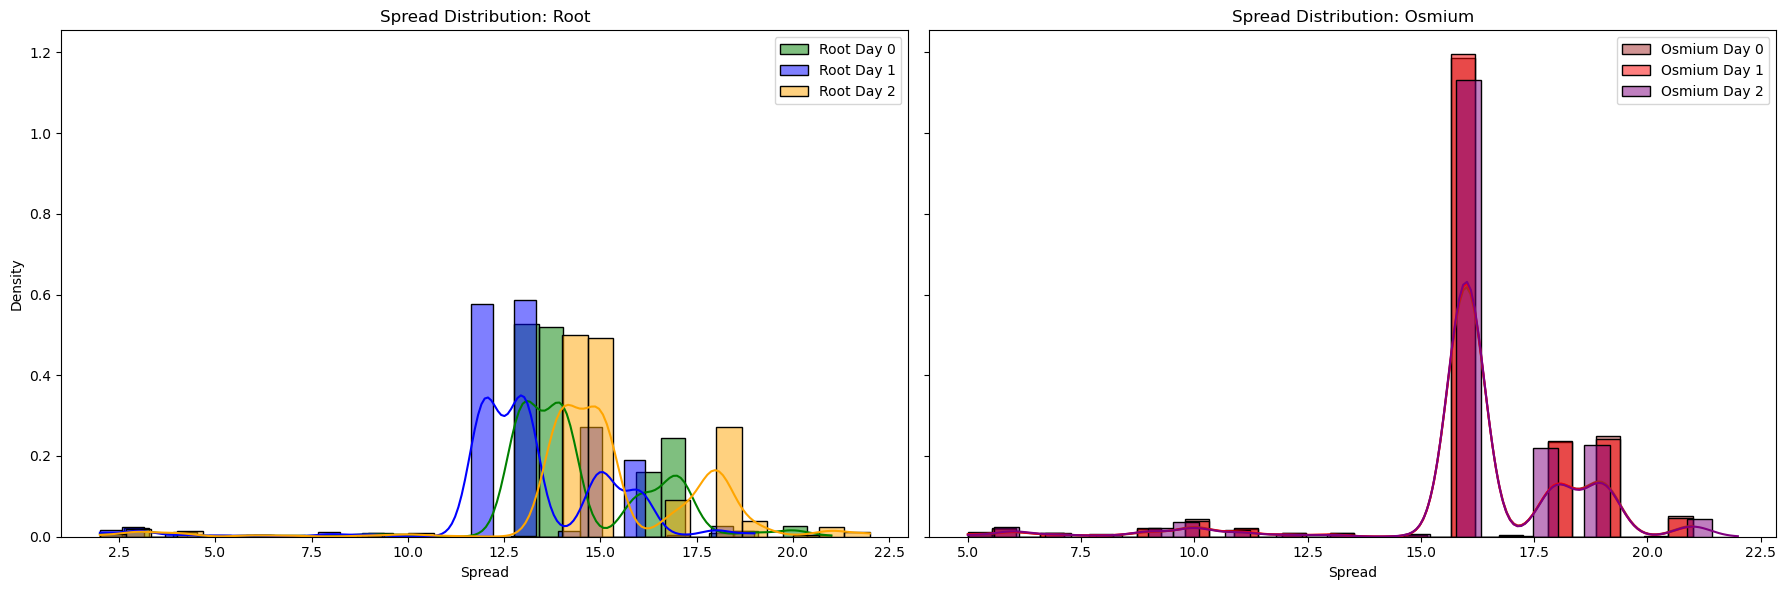

In [4]:
# calculate average price spread for root and osmium
prices_data_01_root["spread"] = prices_data_01_root["ask_price_1"] - prices_data_01_root["bid_price_1"]
prices_data_02_root["spread"] = prices_data_02_root["ask_price_1"] - prices_data_02_root["bid_price_1"]
prices_data_0_root["spread"] = prices_data_0_root["ask_price_1"] - prices_data_0_root["bid_price_1"]
prices_data_01_osmium["spread"] = prices_data_01_osmium["ask_price_1"] - prices_data_01_osmium["bid_price_1"]
prices_data_02_osmium["spread"] = prices_data_02_osmium["ask_price_1"] - prices_data_02_osmium["bid_price_1"]
prices_data_0_osmium["spread"] = prices_data_0_osmium["ask_price_1"] - prices_data_0_osmium["bid_price_1"]


#plot spread distributions for root and osmium on seperate histograms

# Create a figure with 1 row and 2 columns
# sharey=True ensures the vertical scales are the same for direct comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# --- Subplot 1: Root ---
sns.histplot(prices_data_0_root["spread"], label="Root Day 0", color="green", kde=True, stat="density", bins=30, ax=axes[0])
sns.histplot(prices_data_01_root["spread"], label="Root Day 1", color="blue", kde=True, stat="density", bins=30, ax=axes[0])
sns.histplot(prices_data_02_root["spread"], label="Root Day 2", color="orange", kde=True, stat="density", bins=30, ax=axes[0])

axes[0].set_title("Spread Distribution: Root")
axes[0].set_xlabel("Spread")
axes[0].set_ylabel("Density")
axes[0].legend()

# --- Subplot 2: Osmium ---
sns.histplot(prices_data_0_osmium["spread"], label="Osmium Day 0", color="brown", kde=True, stat="density", bins=30, ax=axes[1])
sns.histplot(prices_data_01_osmium["spread"], label="Osmium Day 1", color="red", kde=True, stat="density", bins=30, ax=axes[1])
sns.histplot(prices_data_02_osmium["spread"], label="Osmium Day 2", color="purple", kde=True, stat="density", bins=30, ax=axes[1])

axes[1].set_title("Spread Distribution: Osmium")
axes[1].set_xlabel("Spread")
axes[1].set_ylabel("Density")
axes[1].legend()

# Adjust layout to prevent label overlap
plt.tight_layout()
plt.show()

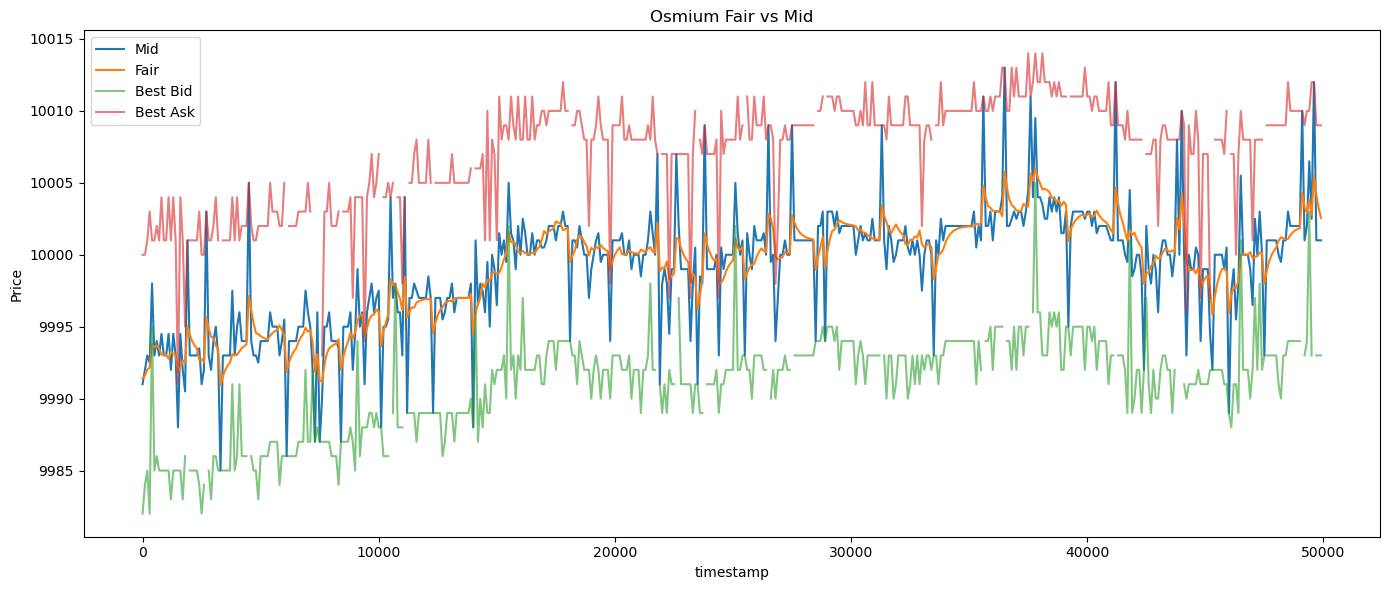

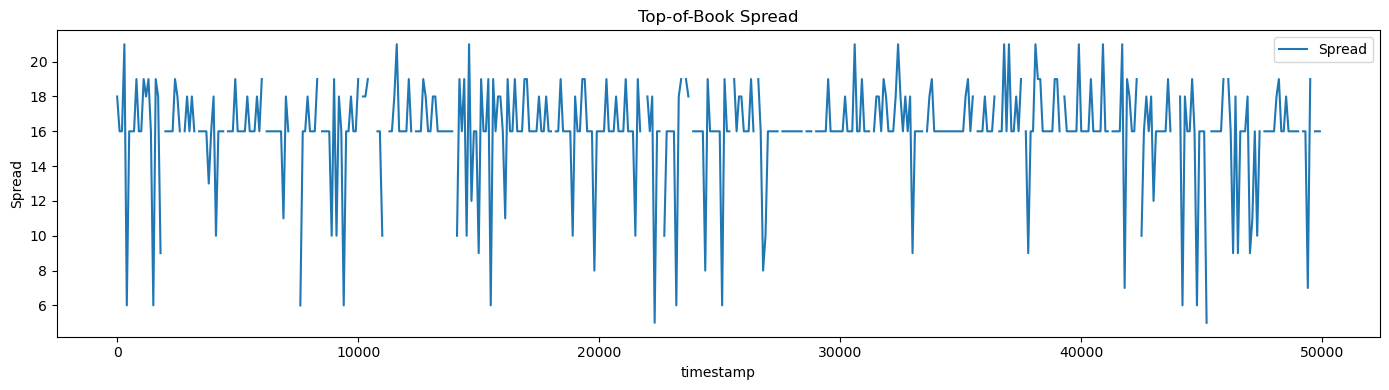

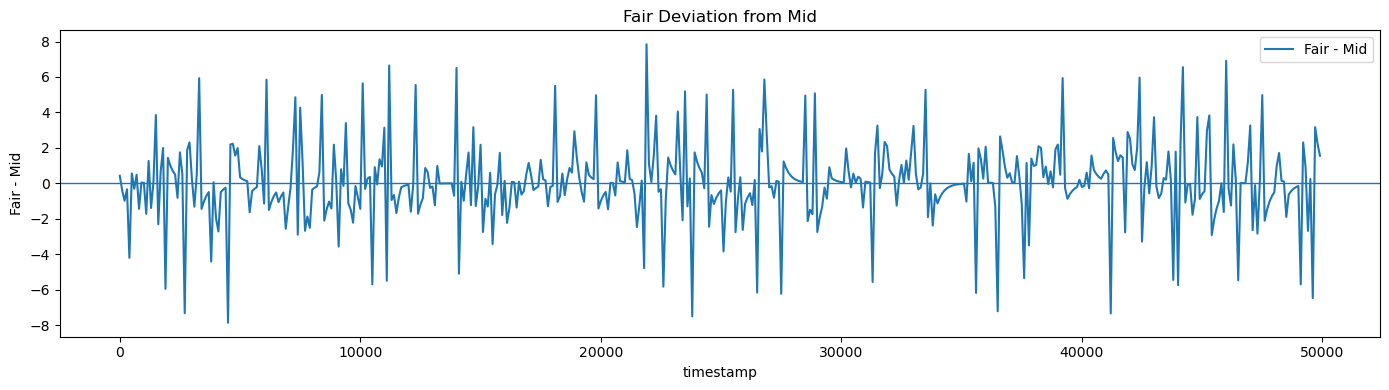

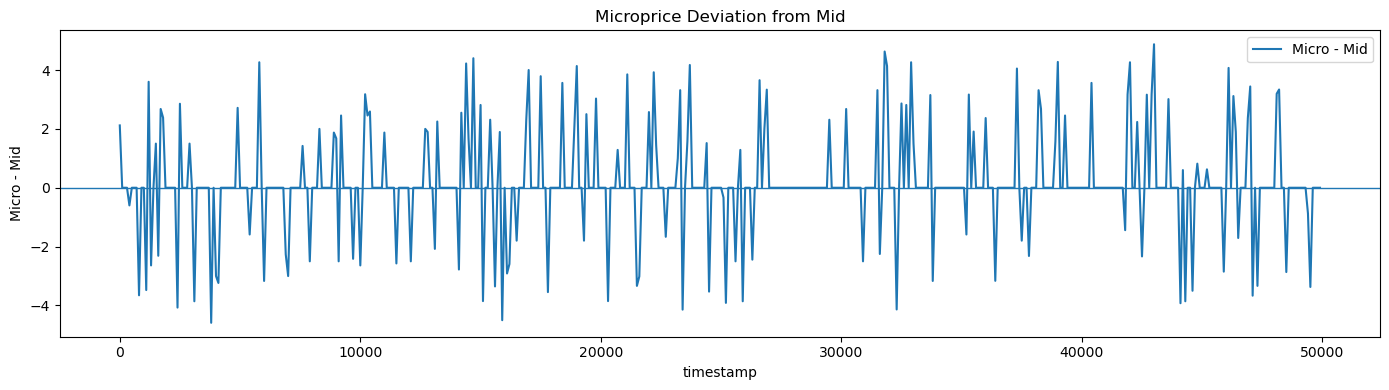

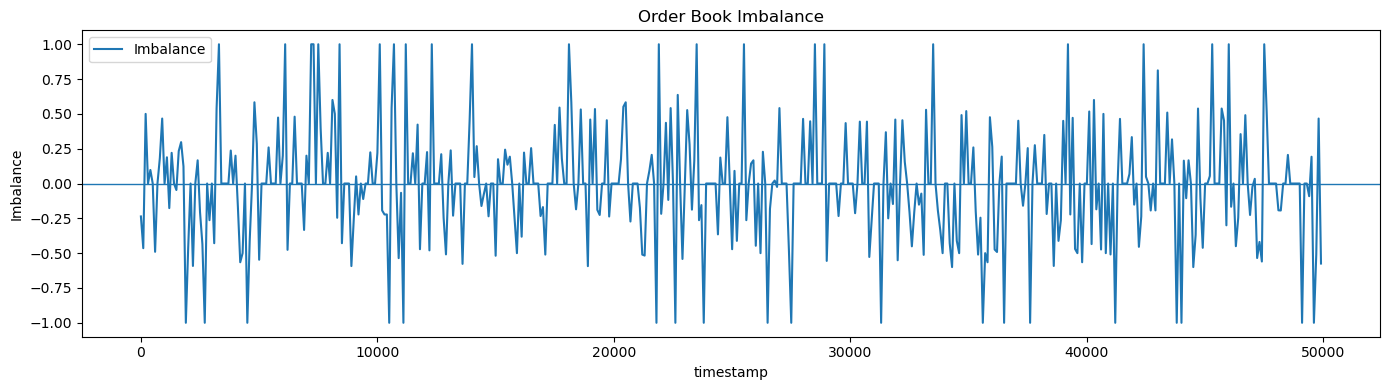

,horizon,correlation_with_future_mid_move,directional_accuracy
0,1,0.651781,0.524927
1,5,0.642072,0.555845
2,10,0.632468,0.564960
3,20,0.607925,0.570151


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def compute_osmium_fair_df(
    df: pd.DataFrame,
    typical_spread: float = 11.0,
    levels: int = 3,
    micro_w: float = 0.4,
    mid_w: float = 0.4,
    anchor_w: float = 0.2,
    use_imbalance: bool = False,
    imbalance_w: float = 0.0,
):
    """
    Standalone fair-value calculator for historical order book data.

    Parameters
    ----------
    df : pd.DataFrame
        Historical order book dataframe.
    typical_spread : float
        Used for fallback fair when only one side exists.
    levels : int
        Number of book levels to use for imbalance, if available.
    micro_w, mid_w, anchor_w : float
        Weights in the fair formula.
    use_imbalance : bool
        Whether to add imbalance adjustment.
    imbalance_w : float
        Weight applied to imbalance term.

    Returns
    -------
    out : pd.DataFrame
        Copy of input df with added columns:
        - best_bid
        - best_ask
        - bid_vol_1
        - ask_vol_1
        - mid
        - spread
        - micro
        - imbalance
        - fair
        - fair_minus_mid
    """

    out = df.copy()

    # -------- column resolution helpers --------
    def first_existing(cols):
        for c in cols:
            if c in out.columns:
                return c
        return None

    best_bid_col = first_existing(["bid_price_1", "best_bid", "bid"])
    best_ask_col = first_existing(["ask_price_1", "best_ask", "ask"])
    bid_vol_1_col = first_existing(["bid_volume_1", "best_bid_volume", "bid_size_1", "bid_qty_1"])
    ask_vol_1_col = first_existing(["ask_volume_1", "best_ask_volume", "ask_size_1", "ask_qty_1"])

    if best_bid_col is None or best_ask_col is None:
        raise ValueError("Could not find top-of-book bid/ask price columns.")

    out["best_bid"] = pd.to_numeric(out[best_bid_col], errors="coerce")
    out["best_ask"] = pd.to_numeric(out[best_ask_col], errors="coerce")

    if bid_vol_1_col is not None:
        out["bid_vol_1"] = pd.to_numeric(out[bid_vol_1_col], errors="coerce").fillna(0.0)
    else:
        out["bid_vol_1"] = 0.0

    if ask_vol_1_col is not None:
        out["ask_vol_1"] = pd.to_numeric(out[ask_vol_1_col], errors="coerce").fillna(0.0)
    else:
        out["ask_vol_1"] = 0.0

    # Make ask volume positive in case stored negative
    out["ask_vol_1"] = out["ask_vol_1"].abs()

    # -------- mid and spread --------
    out["mid"] = np.where(
        out["best_bid"].notna() & out["best_ask"].notna(),
        (out["best_bid"] + out["best_ask"]) / 2.0,
        np.where(
            out["best_bid"].notna(),
            out["best_bid"],
            np.where(out["best_ask"].notna(), out["best_ask"], np.nan),
        ),
    )

    out["spread"] = out["best_ask"] - out["best_bid"]

    # -------- microprice --------
    denom = out["bid_vol_1"] + out["ask_vol_1"]

    out["micro"] = np.where(
        out["best_bid"].notna() & out["best_ask"].notna() & (denom > 0),
        (out["best_bid"] * out["ask_vol_1"] + out["best_ask"] * out["bid_vol_1"]) / denom,
        out["mid"],
    )

    # -------- imbalance --------
    bid_vol_sum = pd.Series(0.0, index=out.index)
    ask_vol_sum = pd.Series(0.0, index=out.index)

    for lvl in range(1, levels + 1):
        bid_vol_col = first_existing([f"bid_volume_{lvl}", f"bid_size_{lvl}", f"bid_qty_{lvl}"])
        ask_vol_col = first_existing([f"ask_volume_{lvl}", f"ask_size_{lvl}", f"ask_qty_{lvl}"])

        if bid_vol_col is not None:
            bid_vol_sum = bid_vol_sum + pd.to_numeric(out[bid_vol_col], errors="coerce").fillna(0.0)

        if ask_vol_col is not None:
            ask_vol_sum = ask_vol_sum + pd.to_numeric(out[ask_vol_col], errors="coerce").fillna(0.0).abs()

    total_vol = bid_vol_sum + ask_vol_sum
    out["imbalance"] = np.where(total_vol > 0, (bid_vol_sum - ask_vol_sum) / total_vol, 0.0)

    # -------- fair calculation with recursive anchor --------
    fair_values = []
    prev_fair = np.nan

    for _, row in out.iterrows():
        best_bid = row["best_bid"]
        best_ask = row["best_ask"]
        mid = row["mid"]
        micro = row["micro"]
        imbalance = row["imbalance"]

        current_prev = prev_fair if not np.isnan(prev_fair) else np.nan

        if pd.notna(micro) and pd.notna(mid):
            anchor = current_prev if pd.notna(current_prev) else mid
            fair = micro_w * micro + mid_w * mid + anchor_w * anchor
            if use_imbalance:
                fair += imbalance_w * imbalance

        elif pd.notna(current_prev):
            if pd.notna(best_bid) and pd.isna(best_ask):
                fair = 0.9 * current_prev + 0.1 * float(best_bid)
            elif pd.notna(best_ask) and pd.isna(best_bid):
                fair = 0.9 * current_prev + 0.1 * float(best_ask)
            else:
                fair = current_prev

        elif pd.notna(best_bid):
            fair = float(best_bid) - typical_spread / 2.0

        elif pd.notna(best_ask):
            fair = float(best_ask) + typical_spread / 2.0

        else:
            fair = np.nan

        fair_values.append(fair)
        prev_fair = fair if pd.notna(fair) else prev_fair

    out["fair"] = fair_values
    out["fair_minus_mid"] = out["fair"] - out["mid"]

    return out


def plot_osmium_fair_diagnostics(
    df_fair: pd.DataFrame,
    ts_col: str = None,
    start: int = None,
    end: int = None,
    show_bid_ask: bool = True,
):
    """
    Plot fair diagnostics from dataframe returned by compute_osmium_fair_df.
    """

    plot_df = df_fair.copy()
    if start is not None or end is not None:
        plot_df = plot_df.iloc[start:end].copy()

    if ts_col is not None and ts_col in plot_df.columns:
        x = plot_df[ts_col]
        xlabel = ts_col
    else:
        x = plot_df.index
        xlabel = "index"


    val = 500
    # 1) Fair vs mid
    plt.figure(figsize=(14, 6))
    plt.plot(x[:val], plot_df["mid"][:val], label="Mid")
    plt.plot(x[:val], plot_df["fair"][:val], label="Fair")
    if show_bid_ask:
        plt.plot(x[:val], plot_df["best_bid"][:val], label="Best Bid", alpha=0.6)
        plt.plot(x[:val], plot_df["best_ask"][:val], label="Best Ask", alpha=0.6)
    plt.title("Osmium Fair vs Mid")
    plt.xlabel(xlabel)
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Spread
    plt.figure(figsize=(14, 4))
    plt.plot(x[:val], plot_df["spread"][:val], label="Spread")
    plt.title("Top-of-Book Spread")
    plt.xlabel(xlabel)
    plt.ylabel("Spread")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Fair minus mid
    plt.figure(figsize=(14, 4))
    plt.plot(x[:val], plot_df["fair_minus_mid"][:val], label="Fair - Mid")
    plt.axhline(0.0, linewidth=1)
    plt.title("Fair Deviation from Mid")
    plt.xlabel(xlabel)
    plt.ylabel("Fair - Mid")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) Micro and imbalance
    if "micro" in plot_df.columns:
        plt.figure(figsize=(14, 4))
        plt.plot(x[:val], plot_df["micro"][:val] - plot_df["mid"][:val], label="Micro - Mid")
        plt.axhline(0.0, linewidth=1)
        plt.title("Microprice Deviation from Mid")
        plt.xlabel(xlabel)
        plt.ylabel("Micro - Mid")
        plt.legend()
        plt.tight_layout()
        plt.show()

    if "imbalance" in plot_df.columns:
        plt.figure(figsize=(14, 4))
        plt.plot(x[:val], plot_df["imbalance"][:val], label="Imbalance")
        plt.axhline(0.0, linewidth=1)
        plt.title("Order Book Imbalance")
        plt.xlabel(xlabel)
        plt.ylabel("Imbalance")
        plt.legend()
        plt.tight_layout()
        plt.show()


def summarize_fair_quality(df_fair: pd.DataFrame, horizons=(1, 5, 10)):
    """
    Quick diagnostic table:
    compares fair-mid deviation with future mid returns.
    This is not a full backtest, just a sanity check.
    """
    out = df_fair.copy()
    results = []

    for h in horizons:
        future_mid = out["mid"].shift(-h)
        future_return = future_mid - out["mid"]

        valid = out["fair_minus_mid"].notna() & future_return.notna()
        if valid.sum() == 0:
            continue

        corr = out.loc[valid, "fair_minus_mid"].corr(future_return.loc[valid])

        directional = np.mean(
            np.sign(out.loc[valid, "fair_minus_mid"]) == np.sign(future_return.loc[valid])
        )

        results.append({
            "horizon": h,
            "correlation_with_future_mid_move": corr,
            "directional_accuracy": directional,
        })

    return pd.DataFrame(results)




# Suppose your historical dataframe is called df
# and maybe has a timestamp column called "timestamp"

df = prices_data_01_osmium.copy()

df_fair = compute_osmium_fair_df(
    df,
    typical_spread=11.0,
    levels=3,
    micro_w=0.2,
    mid_w=0.1,
    anchor_w=0.7,
    use_imbalance=False,
    imbalance_w=0.0,
)

plot_osmium_fair_diagnostics(df_fair, ts_col="timestamp")
summarize_fair_quality(df_fair, horizons=(1, 5, 10, 20))







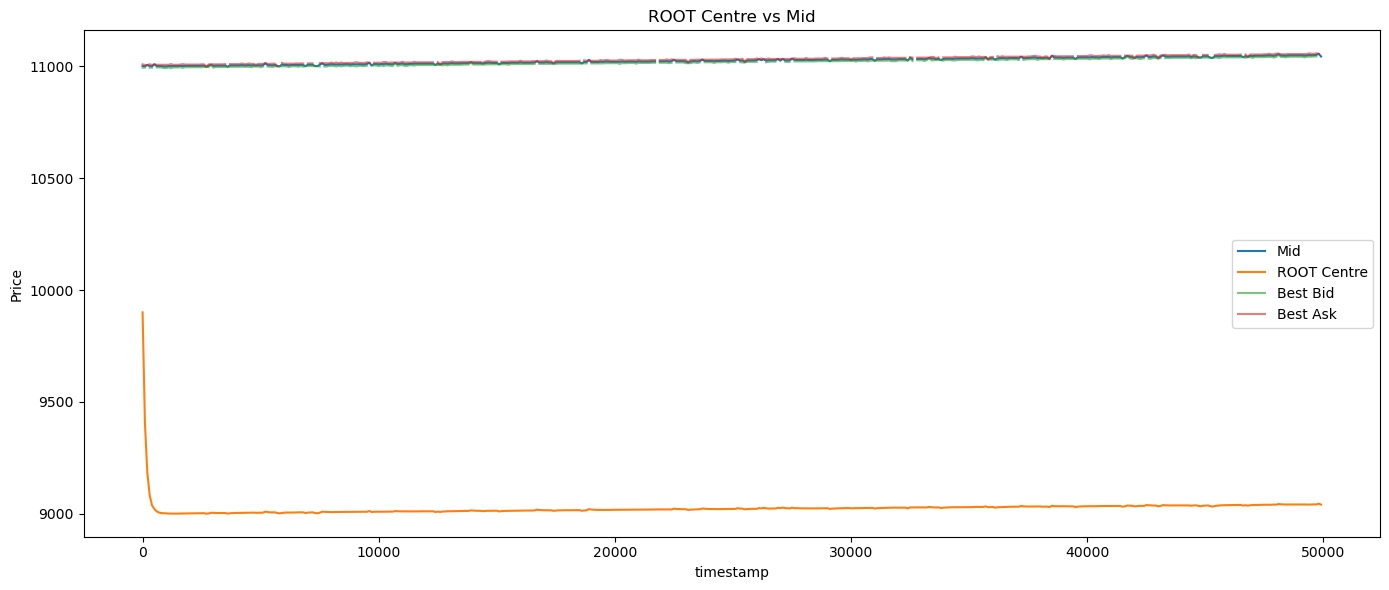

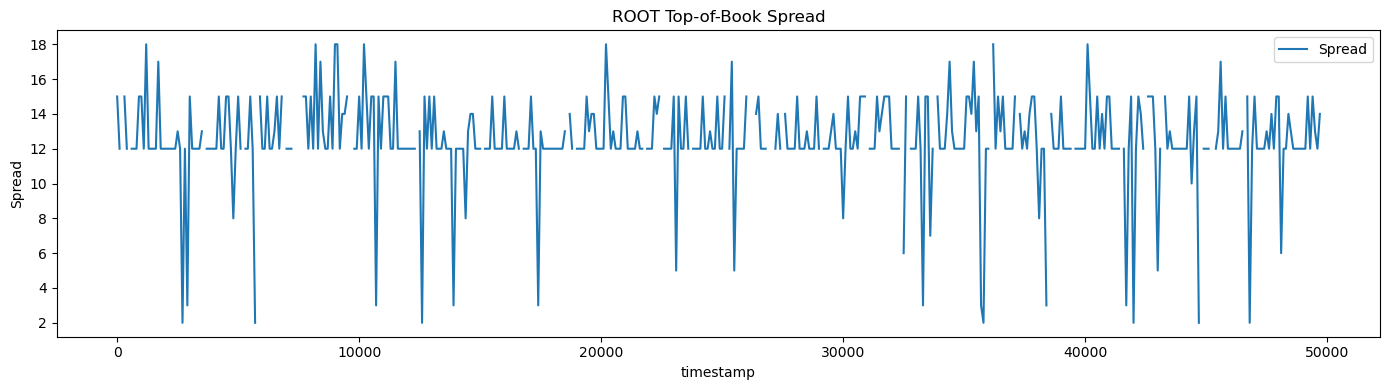

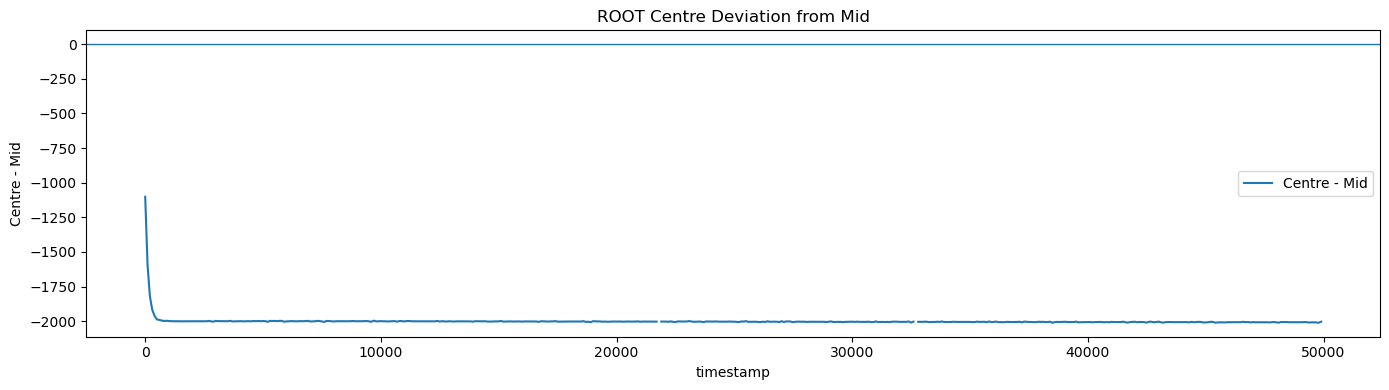

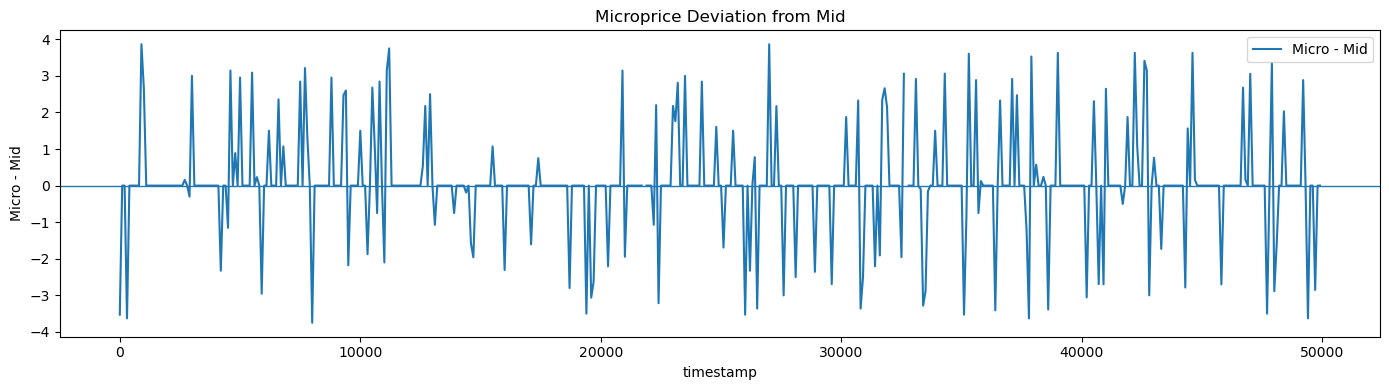

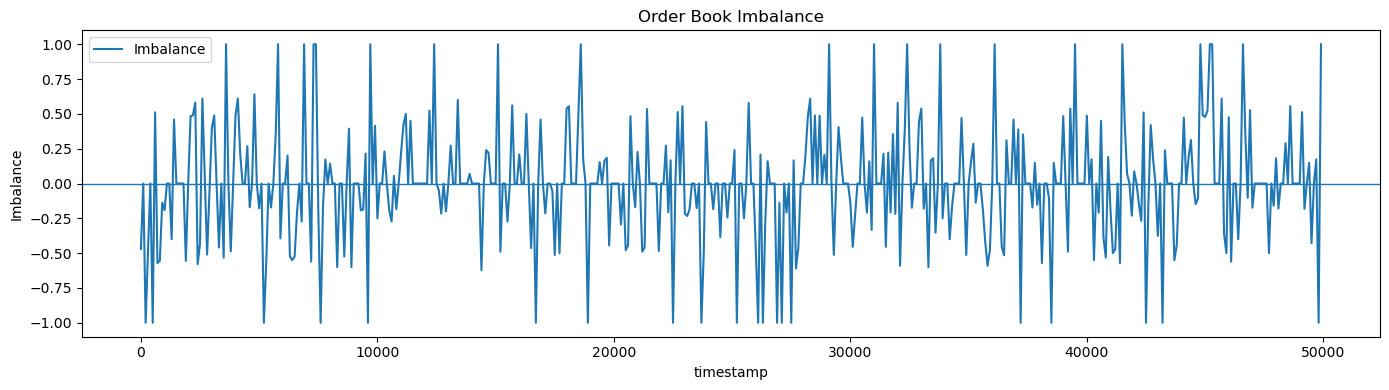

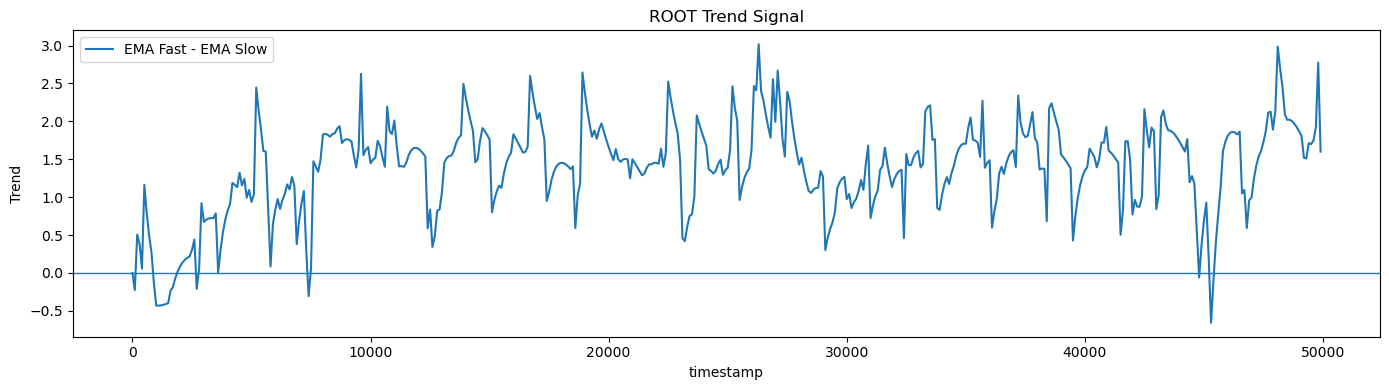

,horizon,correlation_with_future_mid_move,directional_accuracy
0,1,0.016389,0.283465
1,5,0.019297,0.281974
2,10,0.013393,0.267463
3,20,0.013927,0.116335


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = prices_data_01_root.copy()

def compute_root_centre_df(
    df: pd.DataFrame,
    typical_spread: float = 8.0,
    levels: int = 3,
    micro_w: float = 0.30,
    mid_w: float = 0.15,
    anchor_w: float = 0.45,
    trend_w: float = 0.4,
    imbalance_w: float = 0.05,
    fast_alpha: float = 0.20,
    slow_alpha: float = 0.05,
):
    """
    Standalone ROOT centre/fair calculator for historical order book data.

    Parameters
    ----------
    df : pd.DataFrame
        Historical order book dataframe.
    typical_spread : float
        Used for fallback centre when only one side exists.
    levels : int
        Number of book levels to use for imbalance.
    micro_w, mid_w, anchor_w, trend_w, imbalance_w : float
        Weights in the ROOT centre formula.
    fast_alpha, slow_alpha : float
        EMA smoothing parameters.

    Returns
    -------
    out : pd.DataFrame
        Copy of input df with added columns:
        - best_bid
        - best_ask
        - bid_vol_1
        - ask_vol_1
        - mid
        - spread
        - micro
        - imbalance
        - ema_fast
        - ema_slow
        - trend
        - centre
        - centre_minus_mid
        - micro_minus_mid
    """

    out = df.copy()

    def first_existing(cols):
        for c in cols:
            if c in out.columns:
                return c
        return None

    best_bid_col = first_existing(["bid_price_1", "best_bid", "bid"])
    best_ask_col = first_existing(["ask_price_1", "best_ask", "ask"])
    bid_vol_1_col = first_existing(["bid_volume_1", "best_bid_volume", "bid_size_1", "bid_qty_1"])
    ask_vol_1_col = first_existing(["ask_volume_1", "best_ask_volume", "ask_size_1", "ask_qty_1"])

    if best_bid_col is None or best_ask_col is None:
        raise ValueError("Could not find top-of-book bid/ask price columns.")

    out["best_bid"] = pd.to_numeric(out[best_bid_col], errors="coerce")
    out["best_ask"] = pd.to_numeric(out[best_ask_col], errors="coerce")

    if bid_vol_1_col is not None:
        out["bid_vol_1"] = pd.to_numeric(out[bid_vol_1_col], errors="coerce").fillna(0.0)
    else:
        out["bid_vol_1"] = 0.0

    if ask_vol_1_col is not None:
        out["ask_vol_1"] = pd.to_numeric(out[ask_vol_1_col], errors="coerce").fillna(0.0).abs()
    else:
        out["ask_vol_1"] = 0.0

    # Mid
    out["mid"] = np.where(
        out["best_bid"].notna() & out["best_ask"].notna(),
        (out["best_bid"] + out["best_ask"]) / 2.0,
        np.where(
            out["best_bid"].notna(),
            out["best_bid"],
            np.where(out["best_ask"].notna(), out["best_ask"], np.nan),
        ),
    )

    # Spread
    out["spread"] = out["best_ask"] - out["best_bid"]

    # Microprice
    denom = out["bid_vol_1"] + out["ask_vol_1"]
    out["micro"] = np.where(
        out["best_bid"].notna() & out["best_ask"].notna() & (denom > 0),
        (out["best_bid"] * out["ask_vol_1"] + out["best_ask"] * out["bid_vol_1"]) / denom,
        out["mid"],
    )

    # Imbalance from up to `levels` levels if available
    bid_vol_sum = pd.Series(0.0, index=out.index)
    ask_vol_sum = pd.Series(0.0, index=out.index)

    for lvl in range(1, levels + 1):
        bid_vol_col = first_existing([f"bid_volume_{lvl}", f"bid_size_{lvl}", f"bid_qty_{lvl}"])
        ask_vol_col = first_existing([f"ask_volume_{lvl}", f"ask_size_{lvl}", f"ask_qty_{lvl}"])

        if bid_vol_col is not None:
            bid_vol_sum = bid_vol_sum + pd.to_numeric(out[bid_vol_col], errors="coerce").fillna(0.0)

        if ask_vol_col is not None:
            ask_vol_sum = ask_vol_sum + pd.to_numeric(out[ask_vol_col], errors="coerce").fillna(0.0).abs()

    total_vol = bid_vol_sum + ask_vol_sum
    out["imbalance"] = np.where(total_vol > 0, (bid_vol_sum - ask_vol_sum) / total_vol, 0.0)

    # Sequential EMA + centre computation
    ema_fast_vals = []
    ema_slow_vals = []
    trend_vals = []
    centre_vals = []

    prev_ema_fast = np.nan
    prev_ema_slow = np.nan
    prev_centre = np.nan

    for _, row in out.iterrows():
        best_bid = row["best_bid"]
        best_ask = row["best_ask"]
        mid = row["mid"]
        micro = row["micro"]
        imbalance = row["imbalance"]

        # EMA updates
        if pd.notna(mid):
            if np.isnan(prev_ema_fast):
                ema_fast = mid
            else:
                ema_fast = fast_alpha * mid + (1.0 - fast_alpha) * prev_ema_fast

            if np.isnan(prev_ema_slow):
                ema_slow = mid
            else:
                ema_slow = slow_alpha * mid + (1.0 - slow_alpha) * prev_ema_slow
        else:
            ema_fast = prev_ema_fast
            ema_slow = prev_ema_slow

        if pd.notna(ema_fast) and pd.notna(ema_slow):
            trend = ema_fast - ema_slow
        else:
            trend = 0.0

        # Centre logic matching your strategy structure
        if pd.notna(micro) and pd.notna(mid):
            anchor = prev_centre if pd.notna(prev_centre) else mid
            centre = (
                micro_w * micro
                + mid_w * mid
                + anchor_w * anchor
                + trend_w * trend
                + imbalance_w * imbalance
            )

        elif pd.notna(prev_centre):
            if pd.notna(best_bid) and pd.isna(best_ask):
                centre = 0.85 * prev_centre + 0.15 * float(best_bid) + trend_w * trend
            elif pd.notna(best_ask) and pd.isna(best_bid):
                centre = 0.85 * prev_centre + 0.15 * float(best_ask) + trend_w * trend
            else:
                centre = prev_centre + trend_w * trend

        elif pd.notna(best_bid):
            centre = float(best_bid) + trend_w * trend

        elif pd.notna(best_ask):
            centre = float(best_ask) + trend_w * trend

        else:
            centre = np.nan

        ema_fast_vals.append(ema_fast)
        ema_slow_vals.append(ema_slow)
        trend_vals.append(trend)
        centre_vals.append(centre)

        prev_ema_fast = ema_fast if pd.notna(ema_fast) else prev_ema_fast
        prev_ema_slow = ema_slow if pd.notna(ema_slow) else prev_ema_slow
        prev_centre = centre if pd.notna(centre) else prev_centre

    out["ema_fast"] = ema_fast_vals
    out["ema_slow"] = ema_slow_vals
    out["trend"] = trend_vals
    out["centre"] = centre_vals
    out["centre_minus_mid"] = out["centre"] - out["mid"]
    out["micro_minus_mid"] = out["micro"] - out["mid"]

    return out


def plot_root_centre_diagnostics(
    df_root: pd.DataFrame,
    ts_col: str = None,
    start: int = None,
    end: int = None,
    show_bid_ask: bool = True,
):
    """
    Plot ROOT centre diagnostics from dataframe returned by compute_root_centre_df.
    """
    plot_df = df_root.copy()
    if start is not None or end is not None:
        plot_df = plot_df.iloc[start:end].copy()

    if ts_col is not None and ts_col in plot_df.columns:
        x = plot_df[ts_col]
        xlabel = ts_col
    else:
        x = plot_df.index
        xlabel = "index"

    val = 500

    # 1) Centre vs mid
    plt.figure(figsize=(14, 6))
    plt.plot(x[:val], plot_df["mid"][:val], label="Mid")
    plt.plot(x[:val], plot_df["centre"][:val], label="ROOT Centre")
    if show_bid_ask:
        plt.plot(x[:val], plot_df["best_bid"][:val], label="Best Bid", alpha=0.6)
        plt.plot(x[:val], plot_df["best_ask"][:val], label="Best Ask", alpha=0.6)
    plt.title("ROOT Centre vs Mid")
    plt.xlabel(xlabel)
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Spread
    plt.figure(figsize=(14, 4))
    plt.plot(x[:val], plot_df["spread"][:val], label="Spread")
    plt.title("ROOT Top-of-Book Spread")
    plt.xlabel(xlabel)
    plt.ylabel("Spread")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Centre minus mid
    plt.figure(figsize=(14, 4))
    plt.plot(x[:val], plot_df["centre_minus_mid"][:val], label="Centre - Mid")
    plt.axhline(0.0, linewidth=1)
    plt.title("ROOT Centre Deviation from Mid")
    plt.xlabel(xlabel)
    plt.ylabel("Centre - Mid")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) Micro minus mid
    plt.figure(figsize=(14, 4))
    plt.plot(x[:val], plot_df["micro_minus_mid"][:val], label="Micro - Mid")
    plt.axhline(0.0, linewidth=1)
    plt.title("Microprice Deviation from Mid")
    plt.xlabel(xlabel)
    plt.ylabel("Micro - Mid")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 5) Imbalance
    plt.figure(figsize=(14, 4))
    plt.plot(x[:val], plot_df["imbalance"][:val], label="Imbalance")
    plt.axhline(0.0, linewidth=1)
    plt.title("Order Book Imbalance")
    plt.xlabel(xlabel)
    plt.ylabel("Imbalance")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 6) Trend
    plt.figure(figsize=(14, 4))
    plt.plot(x[:val], plot_df["trend"][:val], label="EMA Fast - EMA Slow")
    plt.axhline(0.0, linewidth=1)
    plt.title("ROOT Trend Signal")
    plt.xlabel(xlabel)
    plt.ylabel("Trend")
    plt.legend()
    plt.tight_layout()
    plt.show()


def summarize_root_centre_quality(df_root: pd.DataFrame, horizons=(1, 5, 10)):
    """
    Quick sanity-check table for ROOT centre:
    compares centre-mid deviation with future mid moves.
    """
    out = df_root.copy()
    results = []

    for h in horizons:
        future_mid = out["mid"].shift(-h)
        future_return = future_mid - out["mid"]

        valid = out["centre_minus_mid"].notna() & future_return.notna()
        if valid.sum() == 0:
            continue

        corr = out.loc[valid, "centre_minus_mid"].corr(future_return.loc[valid])
        directional = np.mean(
            np.sign(out.loc[valid, "centre_minus_mid"]) == np.sign(future_return.loc[valid])
        )

        results.append({
            "horizon": h,
            "correlation_with_future_mid_move": corr,
            "directional_accuracy": directional,
        })

    return pd.DataFrame(results)

df_root = compute_root_centre_df(
    df,
    typical_spread=8.0,
    levels=3,
    micro_w=0.30,
    mid_w=0.15,
    anchor_w=0.45,
    trend_w=0.4,
    imbalance_w=0.05,
    fast_alpha=0.20,
    slow_alpha=0.05,
)

plot_root_centre_diagnostics(df_root, ts_col="timestamp")
summarize_root_centre_quality(df_root, horizons=(1, 5, 10, 20))